# Milestone 3 — Odkrywanie procesu i reguł
**PCR Lab Data** | 6 166 przypadków Sample | Process Mining z pm4py

1. Ładowanie danych i konwersja do EventLog
2. DFG (Directly-Follows Graph) — częstość i wydajność
3. Odkrywanie modelu: Alpha Miner · Inductive Miner · IMf · Heuristic Miner
4. Conformance Checking — token-based replay
5. Model BPMN + propozycje usprawnień
6. Reguły decyzyjne (sklearn Decision Tree)
7. Analiza zasobów — endpointy jako proxy usług
8. Wąskie gardła i symulacja Monte Carlo
9. Mini Dashboard HTML (Plotly)

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pm4py
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR   = ROOT / 'results' / 'm3'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
plt.rcParams['figure.dpi']     = 120
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print(f'pm4py {pm4py.__version__}')
print(f'Wyniki -> {RESULTS_DIR}')

pm4py 2.7.22.4
Wyniki -> /mnt/adata-disk/projects/agh/2stopien/BusinessModeling/results/m3


## 1. Ładowanie i przygotowanie danych

In [2]:
df_events = pd.read_parquet(PROCESSED_DIR / 'pcr_events_biz.parquet')
df_cases  = pd.read_parquet(PROCESSED_DIR / 'pcr_cases.parquet')

sample_ids      = set(df_cases[df_cases['process_type'] == 'sample']['instance_uuid'])
df_ev_sample    = df_events[df_events['instance_uuid'].isin(sample_ids)].copy()
df_complete     = df_ev_sample[df_ev_sample['lifecycle'] == 'complete'].copy()
df_start_ev     = df_ev_sample[df_ev_sample['lifecycle'] == 'start'].copy()
df_cases_sample = df_cases[df_cases['process_type'] == 'sample'].copy()

print(f'Przypadki Sample:     {len(sample_ids):>6,}')
print(f'Zdarzenia (lacznie):  {len(df_ev_sample):>6,}')
print(f'  lifecycle=complete: {len(df_complete):>6,}')
print(f'  lifecycle=start:    {len(df_start_ev):>6,}')
print(f'Unikalne aktywnosci:  {df_complete["activity"].nunique():>6}')
print(f'\nRozklad aktywnosci (complete):')
print(df_complete['activity'].value_counts().to_string())

Przypadki Sample:      6,166
Zdarzenia (lacznie):  65,584
  lifecycle=complete: 32,356
  lifecycle=start:    33,228
Unikalne aktywnosci:       8

Rozklad aktywnosci (complete):
activity
Wait for plate validation    6081
Match patient data           6006
Receive sample state         5993
Callback timeout             5766
timeout                      5731
Send notification            1229
Export to EMS                 798
Export result                 752


## 2. DFG — Directly-Follows Graph

- **Frequency DFG**: jak często aktywność A jest bezpośrednio poprzedzona przez B
- **Performance DFG**: mediana czasu przejścia między zdarzeniami complete

Wizualizacja przez networkx/matplotlib — brak zależności od systemowego graphviz.

In [3]:
def compute_dfg(df, case_col='instance_uuid', act_col='activity', ts_col='timestamp'):
    df = df.sort_values([case_col, ts_col]).copy()
    df['_next'] = df.groupby(case_col)[act_col].shift(-1)
    pairs = df.dropna(subset=['_next'])
    dfg   = {(a, b): int(cnt) for (a, b), cnt
             in pairs.groupby([act_col, '_next']).size().items()}
    starts = df.groupby(case_col).first()[act_col].value_counts().to_dict()
    ends   = df.groupby(case_col).last()[act_col].value_counts().to_dict()
    return dfg, starts, ends


def plot_dfg_mpl(dfg, start_acts=None, end_acts=None,
                 title='DFG', min_freq=50, figsize=(14, 8), save_path=None):
    dfg_f = {k: v for k, v in dfg.items() if v >= min_freq}
    G = nx.DiGraph()
    for (s, t), w in dfg_f.items():
        G.add_edge(s, t, weight=w)
    if G.number_of_nodes() == 0:
        print('Brak krawedzi po filtrowaniu.')
        return None

    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        pos = graphviz_layout(G, prog='dot', args='-Grankdir=LR')
    except Exception:
        pos = nx.spring_layout(G, k=2.8, seed=42)

    weights  = [G[u][v]['weight'] for u, v in G.edges()]
    max_w    = max(weights)
    widths   = [0.8 + 5.0 * (w / max_w) ** 0.55 for w in weights]
    e_colors = [plt.cm.YlOrRd(0.25 + 0.75 * (w / max_w) ** 0.5) for w in weights]

    node_in = {n: sum(G[u][v]['weight'] for u, v in G.in_edges(n)) for n in G.nodes()}
    max_nf  = max(node_in.values()) if node_in else 1
    node_colors = []
    for n in G.nodes():
        if start_acts and n in start_acts:
            node_colors.append('#27ae60')
        elif end_acts and n in end_acts:
            node_colors.append('#e74c3c')
        else:
            node_colors.append(plt.cm.Blues(0.28 + 0.65 * (node_in.get(n, 0) / max_nf) ** 0.5))

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=3200, node_shape='s', alpha=0.93)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5, font_weight='bold',
                            labels={n: n.replace(' ', '\n') for n in G.nodes()})
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, edge_color=e_colors,
                           alpha=0.82, arrows=True, arrowsize=22,
                           connectionstyle='arc3,rad=0.06',
                           min_source_margin=28, min_target_margin=28)
    threshold = sorted(weights, reverse=True)[min(5, len(weights) - 1)]
    edge_labels = {(u, v): f"{G[u][v]['weight']:,}"
                   for u, v in G.edges() if G[u][v]['weight'] >= threshold}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax, font_size=6.5, alpha=0.9)

    handles = [
        mpatches.Patch(color='#27ae60', label='Aktywnosc startowa'),
        mpatches.Patch(color='#e74c3c', label='Aktywnosc koncowa'),
        mpatches.Patch(color=plt.cm.Blues(0.7), label='Pozostale'),
    ]
    ax.legend(handles=handles, loc='upper left', fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.axis('off')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
    return fig

Luki DFG (wszystkie):  28
Luki DFG (freq >= 50): 18

Top 15 przejsc:
  Wait for plate validation           -> Receive sample state               : 5,921
  Match patient data                  -> Wait for plate validation          : 5,444
  Receive sample state                -> Callback timeout                   : 4,990
  Callback timeout                    -> timeout                            : 4,812
  timeout                             -> Send notification                  : 1,229
  Match patient data                  -> timeout                            : 498
  Send notification                   -> Wait for plate validation          : 476
  Export result                       -> Export to EMS                      : 447
  Export to EMS                       -> Callback timeout                   : 428
  Receive sample state                -> Export result                      : 396
  Export to EMS                       -> Export result                      : 303
  Receive sample st

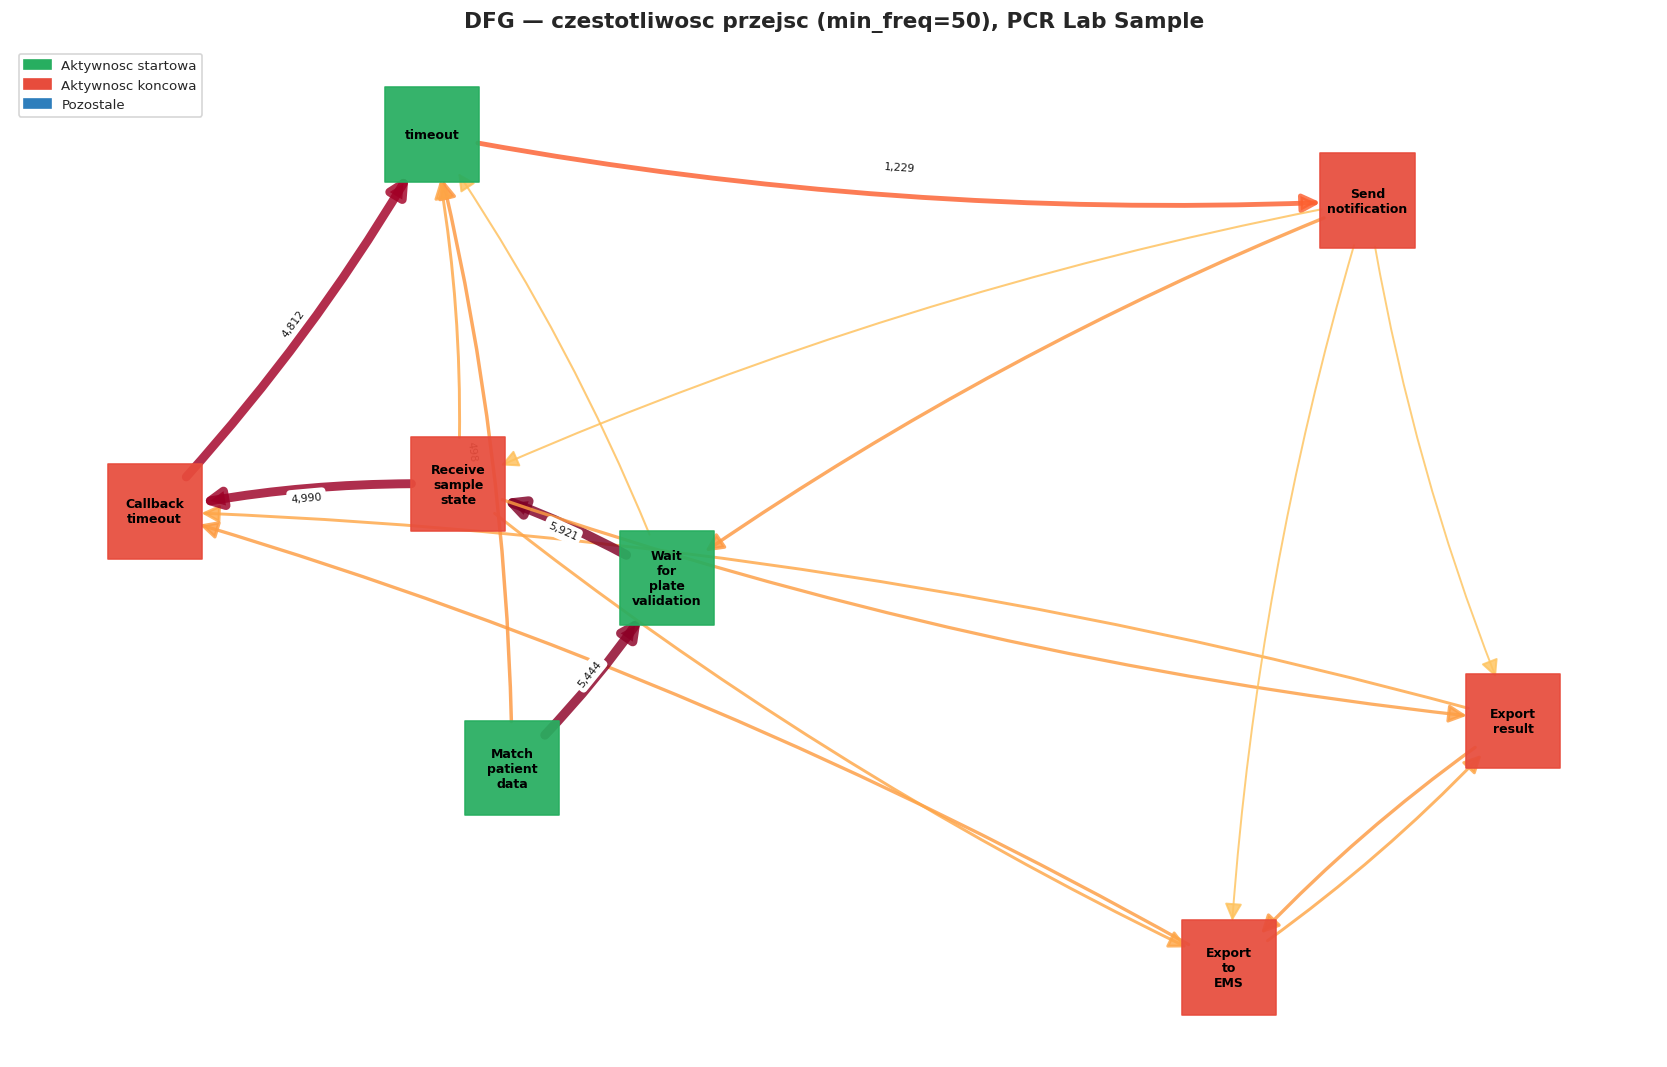

In [4]:
dfg_freq, start_acts, end_acts = compute_dfg(df_complete)

print(f'Luki DFG (wszystkie):  {len(dfg_freq)}')
print(f'Luki DFG (freq >= 50): {sum(1 for v in dfg_freq.values() if v >= 50)}')
print('\nTop 15 przejsc:')
for (s, t), cnt in sorted(dfg_freq.items(), key=lambda x: -x[1])[:15]:
    print(f'  {s:35s} -> {t:35s}: {cnt:,}')

fig_dfg = plot_dfg_mpl(
    dfg_freq, start_acts, end_acts,
    title='DFG — czestotliwosc przejsc (min_freq=50), PCR Lab Sample',
    min_freq=50, figsize=(14, 9),
    save_path=RESULTS_DIR / 'fig_dfg_frequency.png',
)
plt.show()

Czasy aktywnosci (start->complete):
                              n   median_s        mean_s  median_min
activity                                                            
timeout                    5570  10412.721  14781.953620      173.55
Wait for plate validation  6068   9902.160  12398.080546      165.04
Export result               751    321.767   7005.874115        5.36
Export to EMS               795    274.305   6830.687468        4.57
Receive sample state       5993     21.593    463.842524        0.36
Match patient data         6003      6.324    141.709283        0.11
Callback timeout           5766      0.284      0.713473        0.00
Send notification          1229      0.188      0.200704        0.00


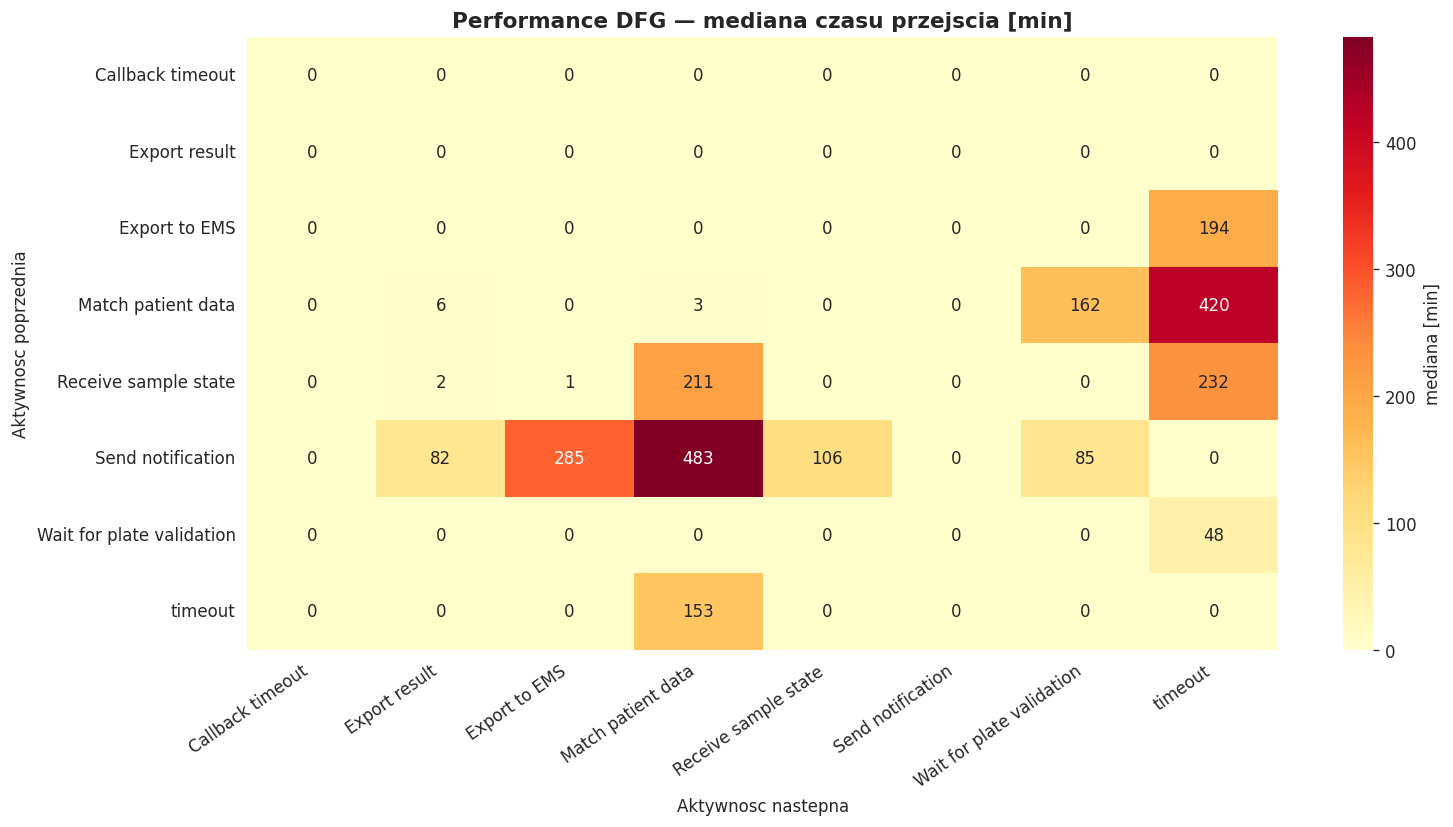


Top 8 najdluzszych przejsc (mediana):
            activity                 _next_act  median_min  count
   Send notification        Match patient data       483.1     11
  Match patient data                   timeout       420.1    498
   Send notification             Export to EMS       284.8     55
Receive sample state                   timeout       232.0    292
Receive sample state        Match patient data       211.1      2
       Export to EMS                   timeout       194.1     39
  Match patient data Wait for plate validation       162.2   5444
             timeout        Match patient data       152.8      1


In [5]:
# Czasy aktywnosci: start -> complete
df_s = df_start_ev.groupby(['instance_uuid', 'activity'])['timestamp'].first()
df_c = df_complete.groupby(['instance_uuid', 'activity'])['timestamp'].first()
common = df_s.index.intersection(df_c.index)
dur_s  = (df_c.loc[common] - df_s.loc[common]).dt.total_seconds()
dur_s  = dur_s[(dur_s >= 0) & (dur_s < 86400)]
df_act_dur = dur_s.reset_index()
df_act_dur.columns = ['instance_uuid', 'activity', 'duration_s']

stats = (df_act_dur.groupby('activity')['duration_s']
         .agg(n='count', median_s='median', mean_s='mean')
         .assign(median_min=lambda x: (x['median_s'] / 60).round(2))
         .sort_values('median_s', ascending=False))
print('Czasy aktywnosci (start->complete):')
print(stats.to_string())

# Performance DFG
df_perf = df_complete.sort_values(['instance_uuid', 'timestamp']).copy()
df_perf['_next_act'] = df_perf.groupby('instance_uuid')['activity'].shift(-1)
df_perf['_next_ts']  = df_perf.groupby('instance_uuid')['timestamp'].shift(-1)
df_perf = df_perf.dropna(subset=['_next_act', '_next_ts']).copy()
df_perf['_dur_s'] = (df_perf['_next_ts'] - df_perf['timestamp']).dt.total_seconds()
df_perf = df_perf[df_perf['_dur_s'] >= 0]

perf_dfg_df = (df_perf.groupby(['activity', '_next_act'])['_dur_s']
               .agg(median='median', mean='mean', count='count')
               .reset_index())

pivot_min = perf_dfg_df.pivot(index='activity', columns='_next_act', values='median').fillna(0) / 60
fig_perf, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_min, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'mediana [min]'})
ax.set_title('Performance DFG — mediana czasu przejscia [min]', fontsize=13, fontweight='bold')
ax.set_xlabel('Aktywnosc nastepna')
ax.set_ylabel('Aktywnosc poprzednia')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
fig_perf.savefig(RESULTS_DIR / 'fig_dfg_performance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 8 najdluzszych przejsc (mediana):')
top_perf = perf_dfg_df.nlargest(8, 'median').copy()
top_perf['median_min'] = (top_perf['median'] / 60).round(1)
print(top_perf[['activity', '_next_act', 'median_min', 'count']].to_string(index=False))

## 3. Odkrywanie modelu procesu

| Algorytm | Charakterystyka |
|---|---|
| **Alpha Miner** | Klasyczny (1987), kontrprzykład — problemy z petlami, brakujace miejsca |
| **Inductive Miner (IM)** | Gwarancja soundness, model blokowy, rekurencyjne dzielenie logu |
| **IMf** (IM Infrequent) | Jak IM + filtrowanie rzadkich sciezek — czystszy model |
| **Heuristic Miner** | Oparty na DFG z progami czestosci, najlepszy dla danych z szumem |

In [6]:
df_pm = pm4py.format_dataframe(
    df_complete.copy(),
    case_id='instance_uuid',
    activity_key='activity',
    timestamp_key='timestamp',
)
log = pm4py.convert_to_event_log(df_pm)

print(f'EventLog: {len(log)} traces, {sum(len(t) for t in log):,} events')
print('Przykladowy trace (pierwsze 5 zdarzen):')
for ev in list(log[0])[:5]:
    print(f'  {ev["concept:name"]}')

EventLog: 6162 traces, 32,356 events
Przykladowy trace (pierwsze 5 zdarzen):
  Match patient data
  Wait for plate validation
  Receive sample state
  Callback timeout
  timeout


In [7]:
def show_petri(net, im, fm, name, fname):
    print(f'  Miejsca: {len(net.places)}, Przejscia: {len(net.transitions)}, Luki: {len(net.arcs)}')
    try:
        from pm4py.visualization.petri_net import visualizer as pn_viz
        gviz = pn_viz.apply(net, im, fm, parameters={'format': 'png'})
        pn_viz.save(gviz, str(RESULTS_DIR / fname))
        from IPython.display import Image, display
        display(Image(str(RESULTS_DIR / fname)))
    except Exception as e:
        print(f'  [Graphviz niedostepny: {e}]')
        visible = [t.label for t in net.transitions if t.label]
        print(f'  Przejscia widzialne: {visible}')

=== Alpha Miner ===
  Miejsca: 15, Przejscia: 8, Luki: 41


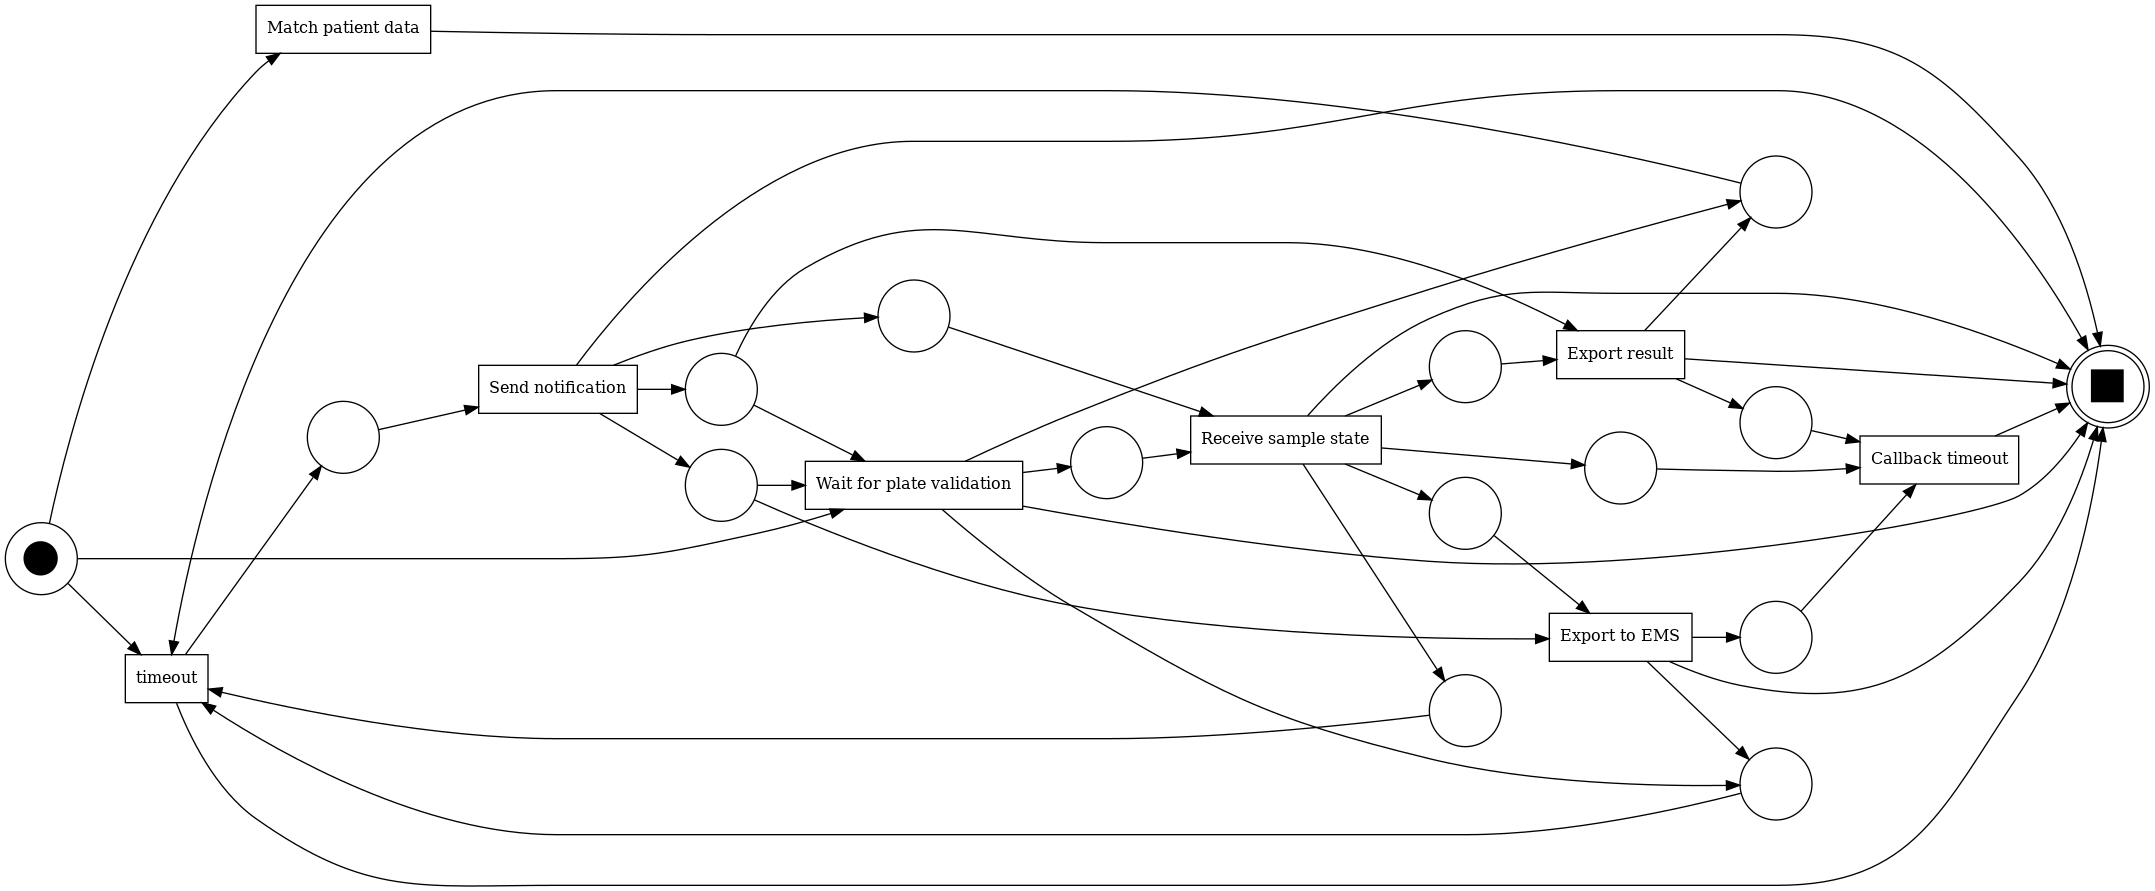

In [8]:
print('=== Alpha Miner ===')
net_alpha, im_alpha, fm_alpha = pm4py.discover_petri_net_alpha(log)
show_petri(net_alpha, im_alpha, fm_alpha, 'Alpha Miner', 'fig_petri_alpha.png')

=== Inductive Miner (IM) ===
  Miejsca: 21, Przejscia: 28, Luki: 64


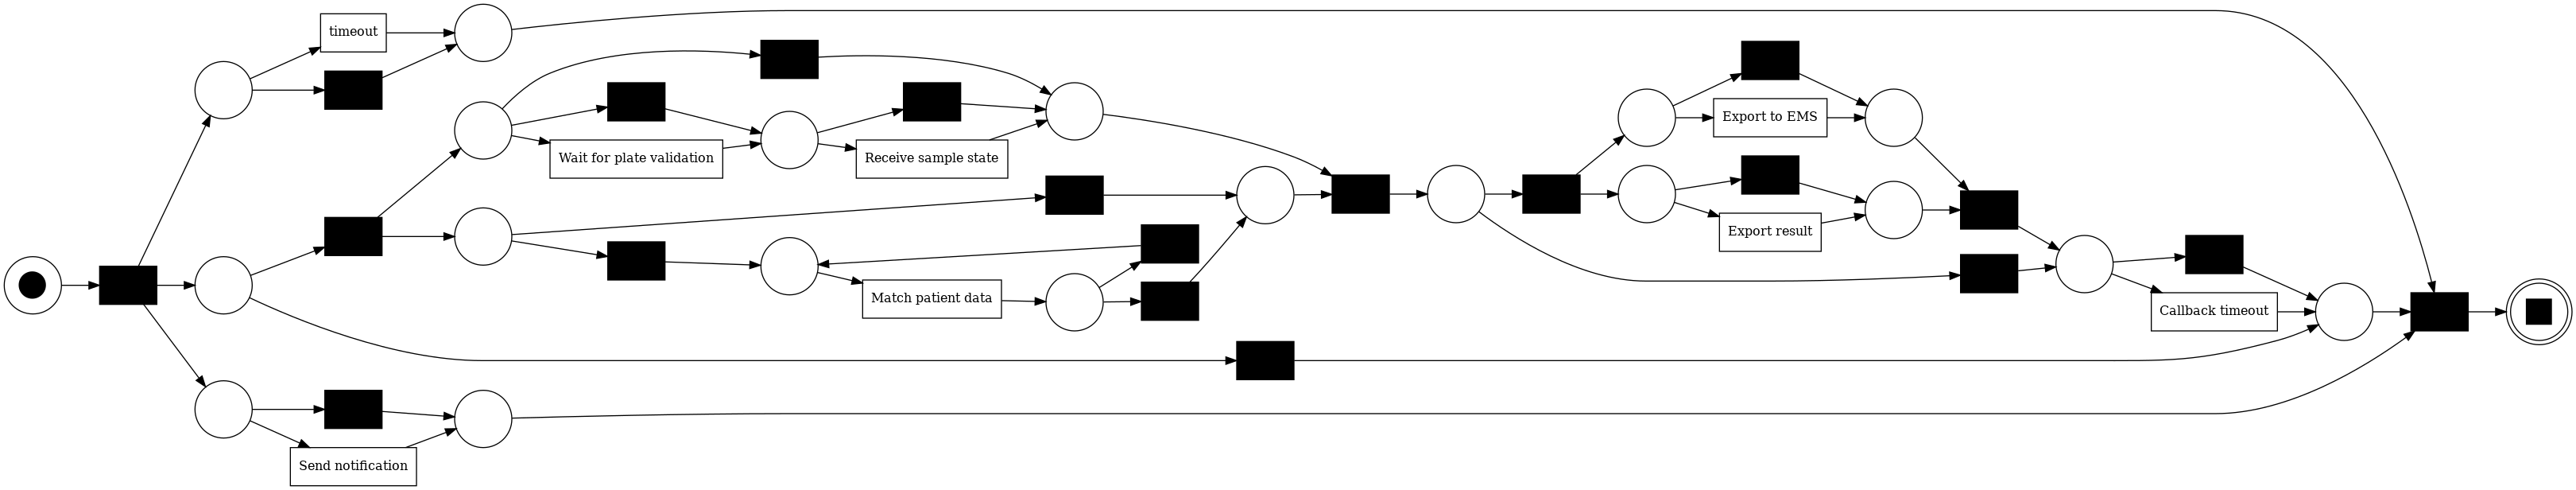

In [9]:
print('=== Inductive Miner (IM) ===')
net_im, im_im, fm_im = pm4py.discover_petri_net_inductive(log)
show_petri(net_im, im_im, fm_im, 'IM', 'fig_petri_im.png')

=== Inductive Miner Infrequent (IMf, noise=0.2) ===
  IM:  21 miejsc, 28 przejsc
  IMf: 12 miejsc, 11 przejsc
  Miejsca: 12, Przejscia: 11, Luki: 26


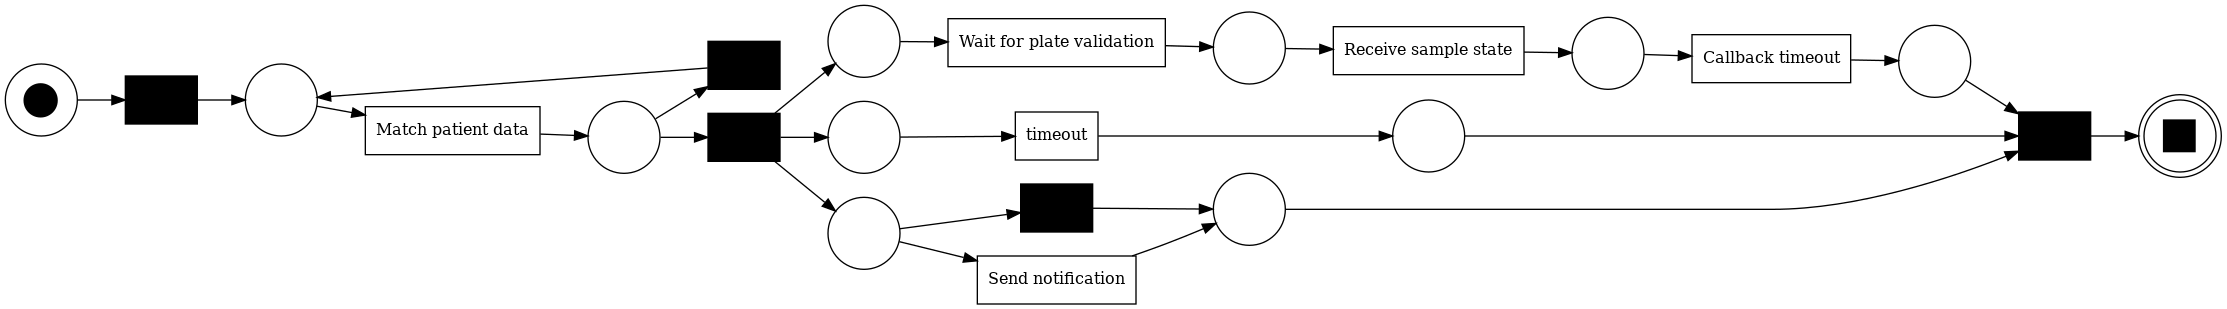

In [10]:
NOISE = 0.2
print(f'=== Inductive Miner Infrequent (IMf, noise={NOISE}) ===')
net_imf, im_imf, fm_imf = pm4py.discover_petri_net_inductive(log, noise_threshold=NOISE)
print(f'  IM:  {len(net_im.places)} miejsc, {len(net_im.transitions)} przejsc')
print(f'  IMf: {len(net_imf.places)} miejsc, {len(net_imf.transitions)} przejsc')
show_petri(net_imf, im_imf, fm_imf, 'IMf', 'fig_petri_imf.png')

=== Heuristic Miner (dep=0.5) ===
  Miejsca: 20, Przejscia: 30, Luki: 69


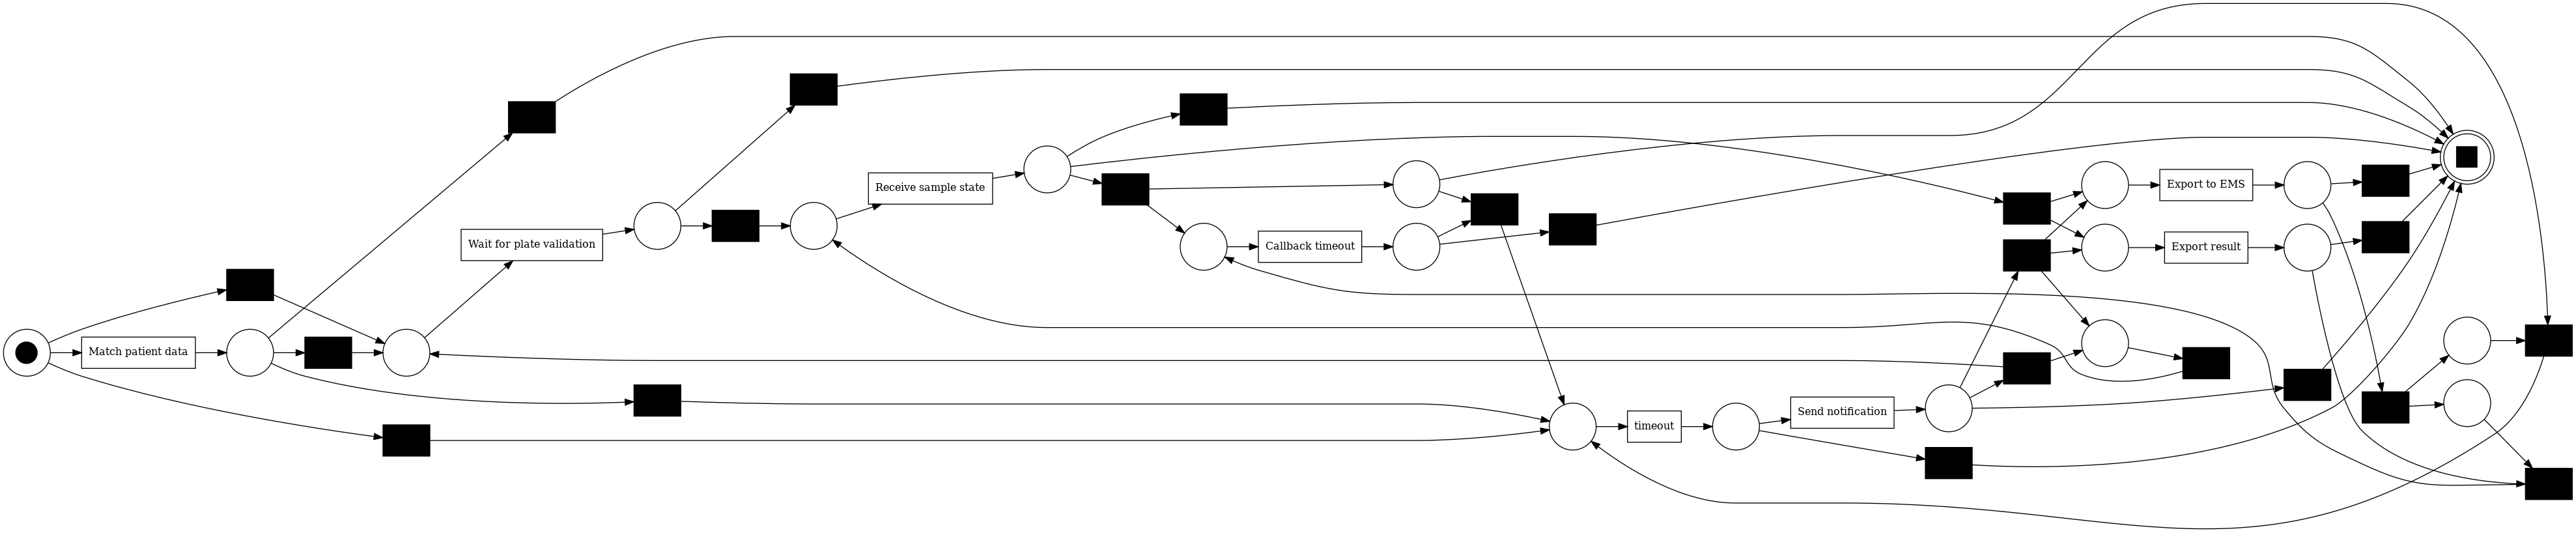

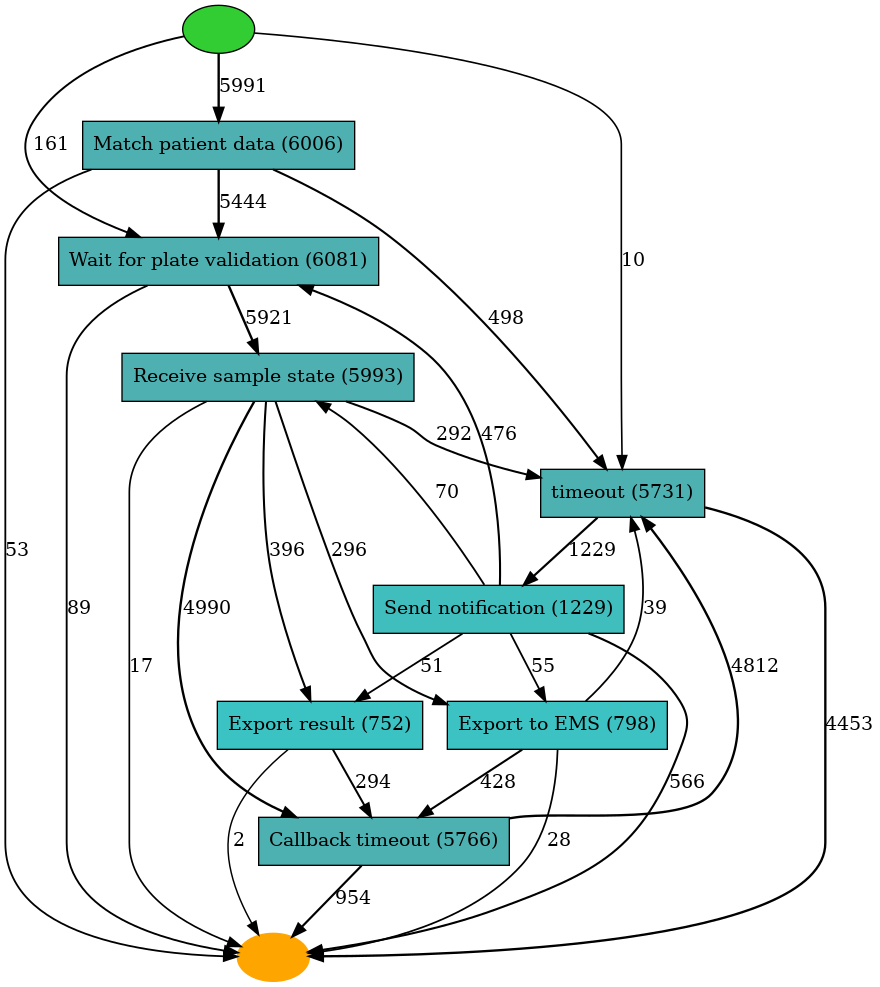

In [11]:
print('=== Heuristic Miner (dep=0.5) ===')
heu_net = pm4py.discover_heuristics_net(log, dependency_threshold=0.5,
                                         and_threshold=0.65, loop_two_threshold=0.5)
net_hm, im_hm, fm_hm = None, None, None
try:
    net_hm, im_hm, fm_hm = pm4py.convert_to_petri_net(heu_net)
    show_petri(net_hm, im_hm, fm_hm, 'HM', 'fig_petri_hm.png')
except Exception as e:
    print(f'  Konwersja HM->Petri: {e}')

try:
    from pm4py.visualization.heuristics_net import visualizer as hn_viz
    gviz = hn_viz.apply(heu_net, parameters={'format': 'png'})
    hn_viz.save(gviz, str(RESULTS_DIR / 'fig_heuristic_net.png'))
    from IPython.display import Image, display
    display(Image(str(RESULTS_DIR / 'fig_heuristic_net.png')))
except Exception as e:
    print(f'  [HN viz: {e}]')

## 4. Analiza zgodności (Conformance Checking)

**Token-based replay**: symuluje wykonanie każdego śladu na sieci Petriego.
- **Fitness**: czy log pasuje do modelu (1.0 = wszystkie ślady pasują)
- **Precision**: czy model nie jest zbyt ogólny (1.0 = model nie pozwala na nic poza logiem)
- **F1**: harmoniczna średnia Fitness i Precision

  Alpha Miner ... 

replaying log with TBR, completed traces :: 100%|██████████| 61/61 [00:00<00:00, 7168.95it/s]

OK
  Inductive (IM) ... 


replaying log with TBR, completed traces :: 100%|██████████| 61/61 [00:00<00:00, 788.51it/s]

OK
  IMf (noise=0.2) ... 


replaying log with TBR, completed traces :: 100%|██████████| 61/61 [00:00<00:00, 2930.83it/s]

OK
  Heuristic Miner ... 


replaying log with TBR, completed traces :: 100%|██████████| 61/61 [00:00<00:00, 1556.07it/s]


OK

       Algorytm  Fitness  % pasujacych tras  Precision     F1  Miejsca  Przejscia
    Alpha Miner   0.5063                0.8     1.0000 0.6722       15          8
 Inductive (IM)   1.0000              100.0     0.4092 0.5807       21         28
IMf (noise=0.2)   0.9595               88.9     0.6952 0.8062       12         11
Heuristic Miner   0.9751               73.1     0.9587 0.9668       20         30


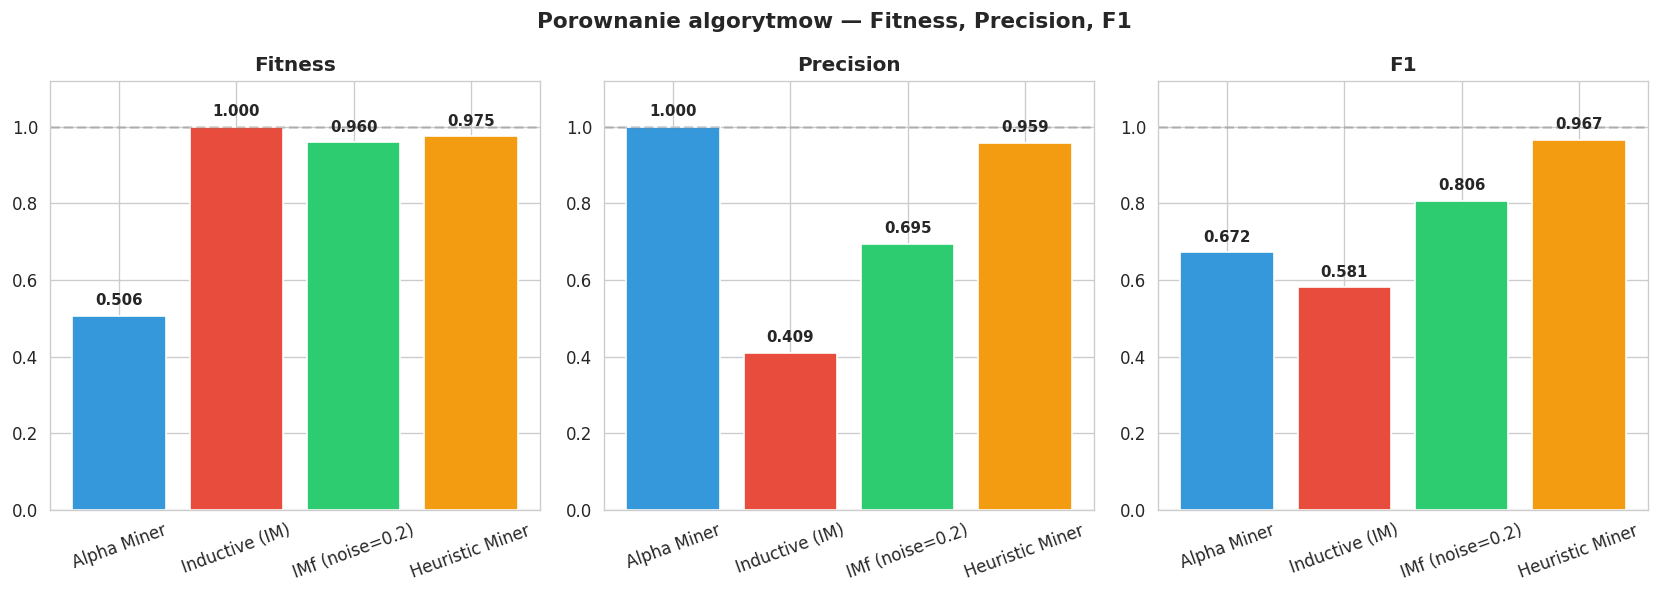

In [12]:
models = {
    'Alpha Miner':     (net_alpha, im_alpha, fm_alpha),
    'Inductive (IM)':  (net_im,    im_im,    fm_im),
    'IMf (noise=0.2)': (net_imf,   im_imf,   fm_imf),
}
if net_hm is not None:
    models['Heuristic Miner'] = (net_hm, im_hm, fm_hm)

rows = []
for name, (net, im, fm) in models.items():
    print(f'  {name} ...', end=' ', flush=True)
    try:
        fit  = pm4py.fitness_token_based_replay(log, net, im, fm)
        prec = pm4py.precision_token_based_replay(log, net, im, fm)
        fv   = fit.get('average_trace_fitness', fit.get('log_fitness', float('nan')))
        pct  = fit.get('percentage_of_fitting_traces', float('nan'))
        f1   = 2 * fv * prec / (fv + prec) if (fv + prec) > 0 else 0
        rows.append({'Algorytm': name, 'Fitness': round(fv, 4),
                     '% pasujacych tras': round(pct, 1),
                     'Precision': round(prec, 4), 'F1': round(f1, 4),
                     'Miejsca': len(net.places), 'Przejscia': len(net.transitions)})
        print('OK')
    except Exception as e:
        print(f'BLAD: {e}')

df_conform = pd.DataFrame(rows)
print()
print(df_conform.to_string(index=False))

fig_cf, axes = plt.subplots(1, 3, figsize=(14, 5))
colors_cf = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for i, metric in enumerate(['Fitness', 'Precision', 'F1']):
    vals = df_conform[metric].fillna(0)
    bars = axes[i].bar(df_conform['Algorytm'], vals, color=colors_cf[:len(df_conform)])
    axes[i].set_ylim(0, 1.12)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].axhline(1.0, color='gray', linestyle='--', alpha=0.4)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.suptitle('Porownanie algorytmow — Fitness, Precision, F1', fontsize=13, fontweight='bold')
plt.tight_layout()
fig_cf.savefig(RESULTS_DIR / 'fig_conformance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Model BPMN i propozycje usprawnień

Najlepszy model: Heuristic Miner


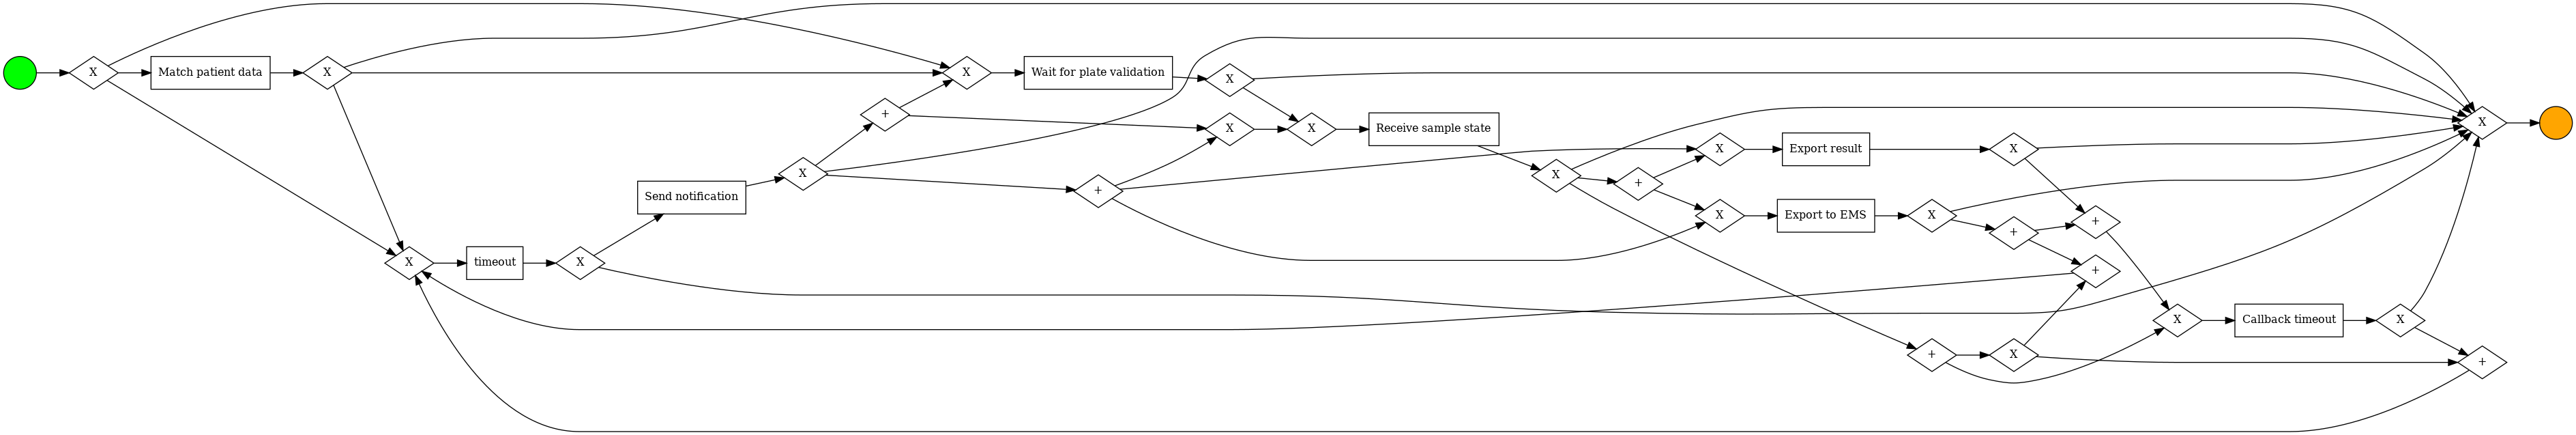


=== PROPOZYCJE USPRAWNIENIA PROCESU ===

1. Optymalizacja Wait for plate validation (~165 min mediana):
   Zmniejszenie rozmiaru partii plytek lub zwiekszenie czestosci
   walidacji moze skrocic ten czas o 30-50%.

2. Rownolegle wykonanie eksportow (AND-split):
   Export result, Export to EMS i Send notification moga byc
   wykonywane rownolegle — oszczednosc ~20-30 min/przypadek.

3. SLA dla przypadkow przekraczajacych 8h:
   ~0.5% przypadkow (outliers z M2) czeka ponad 7h.
   Alert lub priorytet dla wstrzymanych prob.

4. Redukcja overhead timeout CPEE:
   Aktywnosc timeout to mechanizm kolejkowania (~175 min mediana).
   Optymalizacja konfiguracji silnika CPEE.



In [13]:
best_name = df_conform.loc[df_conform['F1'].idxmax(), 'Algorytm']
best_net, best_im, best_fm = models[best_name]
print(f'Najlepszy model: {best_name}')

try:
    bpmn_graph = pm4py.convert_to_bpmn(best_net, best_im, best_fm)
    try:
        from pm4py.visualization.bpmn import visualizer as bpmn_viz
        gviz = bpmn_viz.apply(bpmn_graph, parameters={'format': 'png'})
        bpmn_viz.save(gviz, str(RESULTS_DIR / 'fig_bpmn.png'))
        from IPython.display import Image, display
        display(Image(str(RESULTS_DIR / 'fig_bpmn.png')))
    except Exception as e:
        nodes_cnt = len(list(bpmn_graph.get_nodes()))
        flows_cnt = len(list(bpmn_graph.get_flows()))
        print(f'  BPMN: {nodes_cnt} wezlow, {flows_cnt} przeplywow')
        print(f'  [Wizualizacja: {e}]')
except Exception as e:
    print(f'Konwersja BPMN: {e}')

print('''
=== PROPOZYCJE USPRAWNIENIA PROCESU ===

1. Optymalizacja Wait for plate validation (~165 min mediana):
   Zmniejszenie rozmiaru partii plytek lub zwiekszenie czestosci
   walidacji moze skrocic ten czas o 30-50%.

2. Rownolegle wykonanie eksportow (AND-split):
   Export result, Export to EMS i Send notification moga byc
   wykonywane rownolegle — oszczednosc ~20-30 min/przypadek.

3. SLA dla przypadkow przekraczajacych 8h:
   ~0.5% przypadkow (outliers z M2) czeka ponad 7h.
   Alert lub priorytet dla wstrzymanych prob.

4. Redukcja overhead timeout CPEE:
   Aktywnosc timeout to mechanizm kolejkowania (~175 min mediana).
   Optymalizacja konfiguracji silnika CPEE.
''')

## 6. Odkrycie reguł decyzyjnych

1. **Predykcja wyniku PCR** — czy cechy procesu determinują POSITIVE/NEGATIVE?
2. **Predykcja wariantu** — co determinuje obecność aktywności eksportu?

In [14]:
df_sorted_c = df_complete.sort_values(['instance_uuid', 'timestamp'])
traces = (df_sorted_c.groupby('instance_uuid')['activity']
          .apply(lambda x: ' -> '.join(x))
          .reset_index()
          .rename(columns={'activity': 'trace'}))

variant_counts = traces['trace'].value_counts()
main_variant   = variant_counts.index[0]
print(f'Wariantow: {len(variant_counts)}')
print(f'Top wariant ({variant_counts.iloc[0]} przypadkow, '
      f'{100*variant_counts.iloc[0]/len(traces):.1f}%):')
print(f'  {main_variant[:120]}')

feat = df_cases_sample.merge(traces, on='instance_uuid', how='left')
feat['hour']            = feat['first_ts'].dt.hour
feat['dayofweek']       = feat['first_ts'].dt.dayofweek
feat['is_main_variant'] = (feat['trace'] == main_variant).astype(int)
feat['has_export']      = feat['trace'].str.contains('Export', na=False).astype(int)
feat['has_notification']= feat['trace'].str.contains('Send notification', na=False).astype(int)
feat['pcr_binary']      = (feat['pcr_result'] == 'POSITIVE').astype(int)

feat_clean = feat.dropna(subset=['duration_min', 'pcr_result']).copy()
print(f'Cases z pelna informacja: {len(feat_clean):,}')
print(f'Udzial is_main_variant:  {feat_clean["is_main_variant"].mean():.1%}')
print(f'Udzial has_export:       {feat_clean["has_export"].mean():.1%}')
print(f'Udzial has_notification: {feat_clean["has_notification"].mean():.1%}')

Wariantow: 47
Top wariant (4008 przypadkow, 65.0%):
  Match patient data -> Wait for plate validation -> Receive sample state -> Callback timeout -> timeout
Cases z pelna informacja: 5,993
Udzial is_main_variant:  66.9%
Udzial has_export:       13.3%
Udzial has_notification: 20.1%


=== Drzewo: predykcja pcr_result ===
Baseline (klasa wiodaca):  0.530
CV Accuracy (5-fold):      0.645 +/- 0.009
Waznosc cech:
  n_events            : 0.7515
  hour                : 0.1237
  duration_min        : 0.1010
  dayofweek           : 0.0238

Wniosek: wynik PCR nie jest predykowalny z cech procesu.
Potwierdza findings M1 — czas i przebieg niezalezne od wyniku.


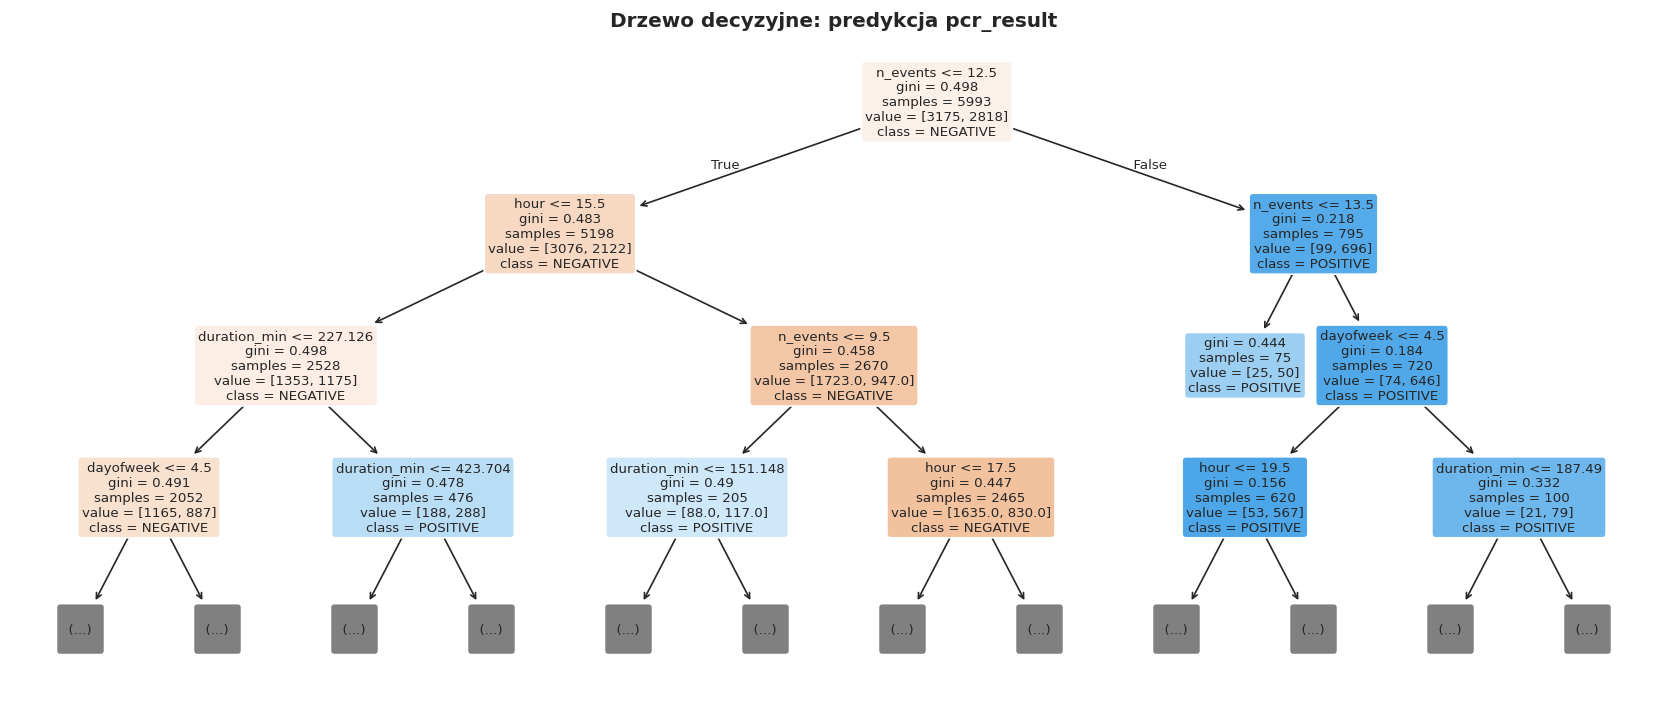

In [15]:
FEAT1 = ['duration_min', 'n_events', 'hour', 'dayofweek']
X1, y1 = feat_clean[FEAT1], feat_clean['pcr_binary']

dt_pcr = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=RANDOM_STATE)
cv1    = cross_val_score(dt_pcr, X1, y1, cv=5, scoring='accuracy')
dt_pcr.fit(X1, y1)

print('=== Drzewo: predykcja pcr_result ===')
print(f'Baseline (klasa wiodaca):  {max(y1.mean(), 1 - y1.mean()):.3f}')
print(f'CV Accuracy (5-fold):      {cv1.mean():.3f} +/- {cv1.std():.3f}')
print('Waznosc cech:')
for n, imp in sorted(zip(FEAT1, dt_pcr.feature_importances_), key=lambda x: -x[1]):
    print(f'  {n:<20}: {imp:.4f}')
print('\nWniosek: wynik PCR nie jest predykowalny z cech procesu.')
print('Potwierdza findings M1 — czas i przebieg niezalezne od wyniku.')

fig_dt1, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt_pcr, feature_names=FEAT1, class_names=['NEGATIVE', 'POSITIVE'],
          filled=True, rounded=True, ax=ax, fontsize=8, max_depth=3)
ax.set_title('Drzewo decyzyjne: predykcja pcr_result', fontweight='bold')
plt.tight_layout()
fig_dt1.savefig(RESULTS_DIR / 'fig_dt_pcr_result.png', dpi=120, bbox_inches='tight')
plt.show()

is_main_variant            base=0.669  CV=0.995+/-0.002  top_feat=n_events
has_export                 base=0.867  CV=0.999+/-0.001  top_feat=n_events
has_notification           base=0.799  CV=0.980+/-0.003  top_feat=duration_min


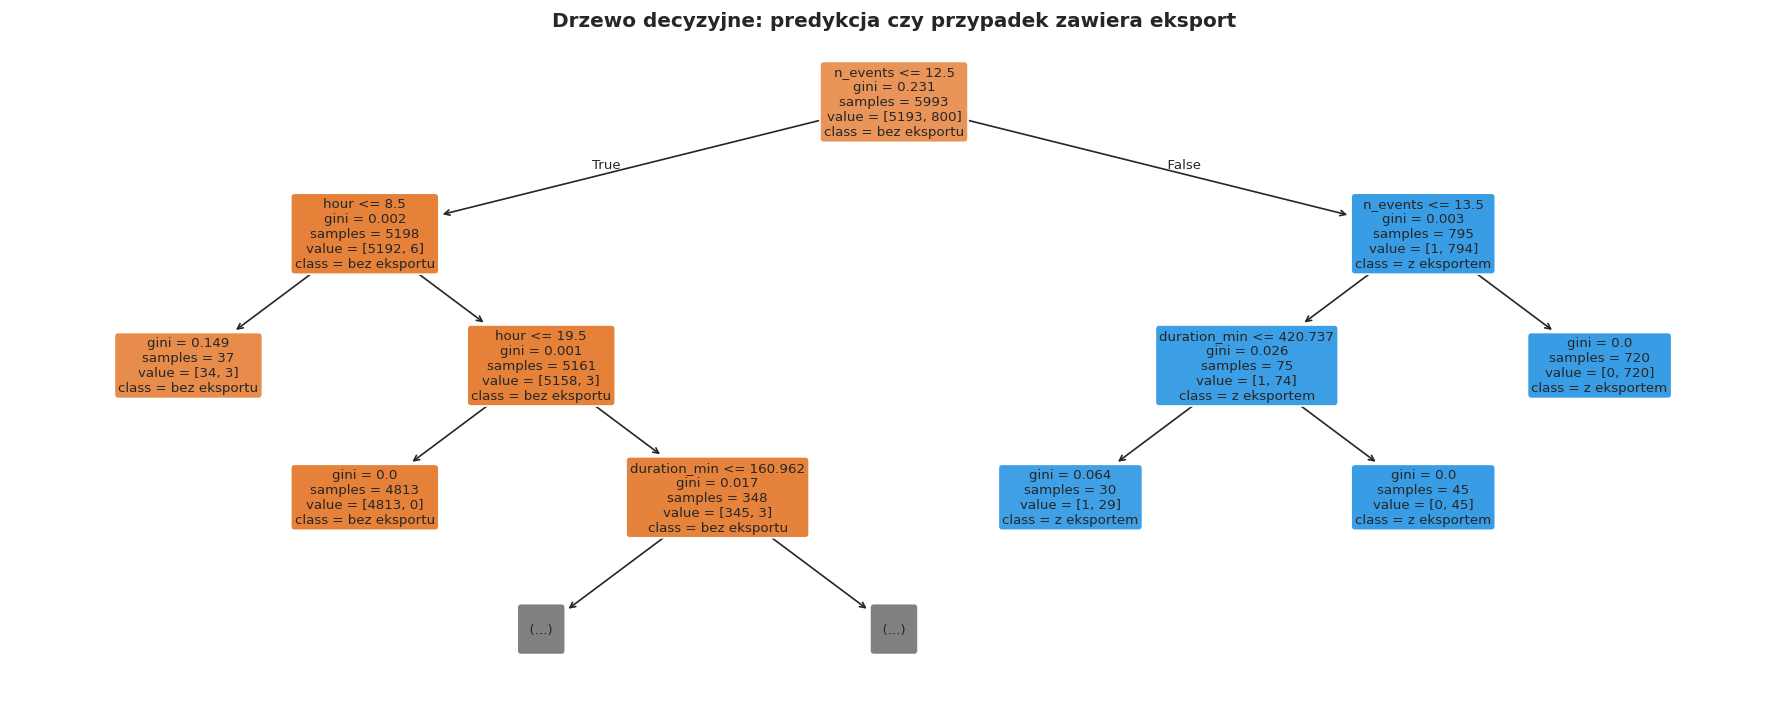


Reguly tekstowe (depth=2):
|--- n_events <= 12.50
|   |--- hour <= 8.50
|   |   |--- class: 0
|   |--- hour >  8.50
|   |   |--- hour <= 19.50
|   |   |   |--- class: 0
|   |   |--- hour >  19.50
|   |   |   |--- truncated branch of depth 2
|--- n_events >  12.50
|   |--- n_events <= 13.50
|   |   |--- duration_min <= 420.74
|   |   |   |--- class: 1
|   |   |--- duration_min >  420.74
|   |   |   |--- class: 1
|   |--- n_events >  13.50
|   |   |--- class: 1



In [16]:
FEAT2 = ['duration_min', 'n_events', 'hour', 'dayofweek', 'pcr_binary']
X2    = feat_clean[FEAT2]

for tgt_name, tgt_col in [('is_main_variant', 'is_main_variant'),
                           ('has_export',      'has_export'),
                           ('has_notification','has_notification')]:
    y2  = feat_clean[tgt_col]
    dt2 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=RANDOM_STATE)
    cv2 = cross_val_score(dt2, X2, y2, cv=5)
    dt2.fit(X2, y2)
    top = FEAT2[dt2.feature_importances_.argmax()]
    base= max(y2.mean(), 1 - y2.mean())
    print(f'{tgt_name:25s}  base={base:.3f}  CV={cv2.mean():.3f}+/-{cv2.std():.3f}  top_feat={top}')

y_exp  = feat_clean['has_export']
dt_exp = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=RANDOM_STATE)
dt_exp.fit(X2, y_exp)

fig_dt2, ax = plt.subplots(figsize=(15, 6))
plot_tree(dt_exp, feature_names=FEAT2, class_names=['bez eksportu', 'z eksportem'],
          filled=True, rounded=True, ax=ax, fontsize=8, max_depth=3)
ax.set_title('Drzewo decyzyjne: predykcja czy przypadek zawiera eksport', fontweight='bold')
plt.tight_layout()
fig_dt2.savefig(RESULTS_DIR / 'fig_dt_variant.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nReguly tekstowe (depth=2):')
print(export_text(dt_exp, feature_names=FEAT2, max_depth=2))

## 7. Analiza zasobów — endpointy jako proxy usług

> **Uwaga metodyczna**: log PCR Lab nie zawiera identyfikatorów pracowników/maszyn.
> Używamy **endpointów URL** jako reprezentacji mikrousług CPEE — każdy endpoint
> odpowiada konkretnej usłudze laboratoryjnej (korelator, timeout, powiadomienia, itp.).

Zdarzenia start z endpointem: 33,228
Endpointy raw: 8, norm: 8

Top 12 endpointow:
ep_short
mygreschner.com//backend/corr                             11340
mygreschner.com/backend/services/timeout2                  9831
GET:cpee.org/ing/correlators/message/receive               6169
greschner.azurewebsites.net/backend/corr                   2555
greschner.azurewebsites.net/backend/services/timeout       1470
mygreschner.com/backend/services/notifyall                 1027
greschner.azurewebsites.net/backend/services/timeout2       634
greschner.azurewebsites.net/backend/services/notifyall      202


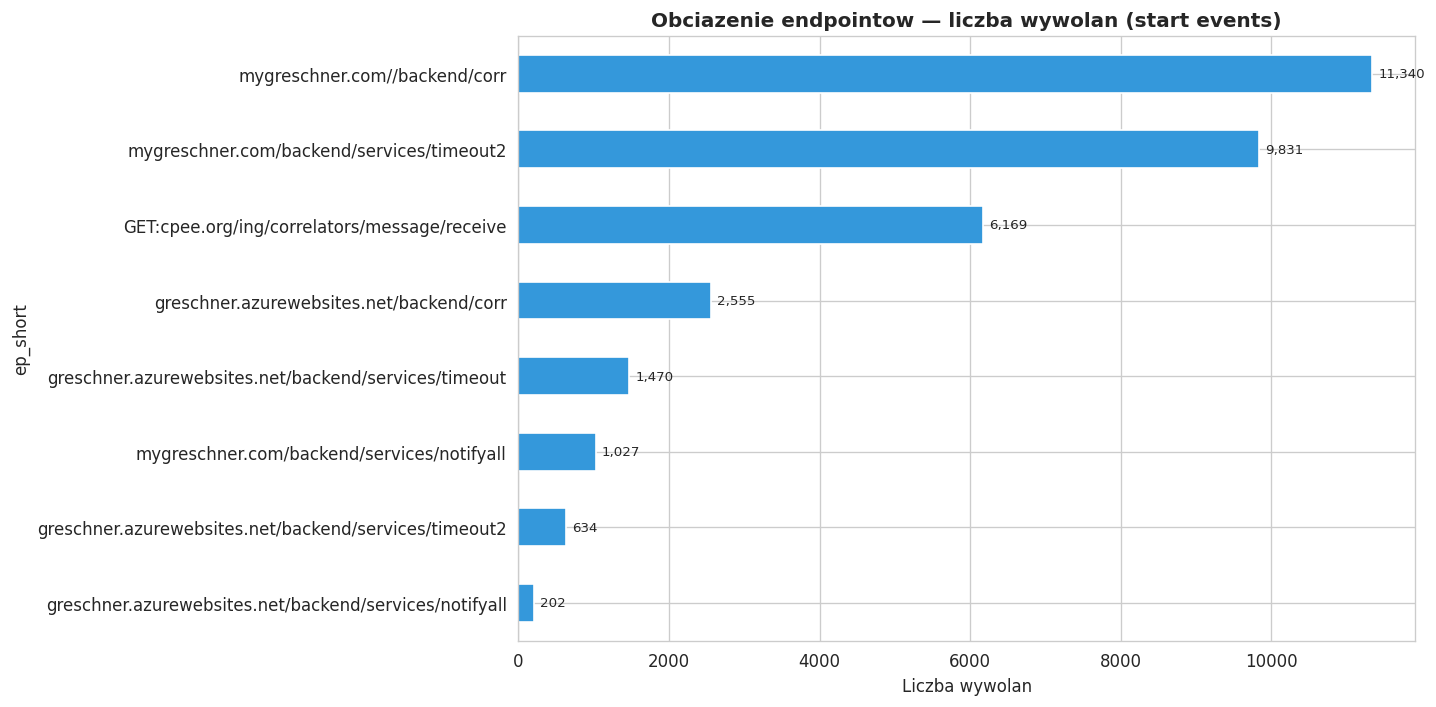

In [17]:
def normalize_ep(url):
    return re.sub(r'/engine/\d+/', '/engine/{id}/', str(url))

def shorten_ep(url):
    url = (url.replace('https://', '')
              .replace('https-get://', 'GET:')
              .replace('https-post://', 'POST:'))
    url = url.rstrip('/')
    return url[:52] + '...' if len(url) > 55 else url

df_res = df_start_ev[
    df_start_ev['endpoint'].notna() & (df_start_ev['endpoint'] != '')
].copy()
df_res['ep_norm']  = df_res['endpoint'].apply(normalize_ep)
df_res['ep_short'] = df_res['ep_norm'].apply(shorten_ep)

ep_workload = df_res['ep_short'].value_counts()
print(f'Zdarzenia start z endpointem: {len(df_res):,}')
print(f'Endpointy raw: {df_res["endpoint"].nunique()}, norm: {df_res["ep_norm"].nunique()}')
print(f'\nTop 12 endpointow:')
print(ep_workload.head(12).to_string())

fig_ep, ax = plt.subplots(figsize=(12, 6))
ep_workload.head(12).sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_xlabel('Liczba wywolan')
ax.set_title('Obciazenie endpointow — liczba wywolan (start events)', fontweight='bold')
for i, v in enumerate(ep_workload.head(12).sort_values()):
    ax.text(v + 80, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
fig_ep.savefig(RESULTS_DIR / 'fig_resource_workload.png', dpi=120, bbox_inches='tight')
plt.show()

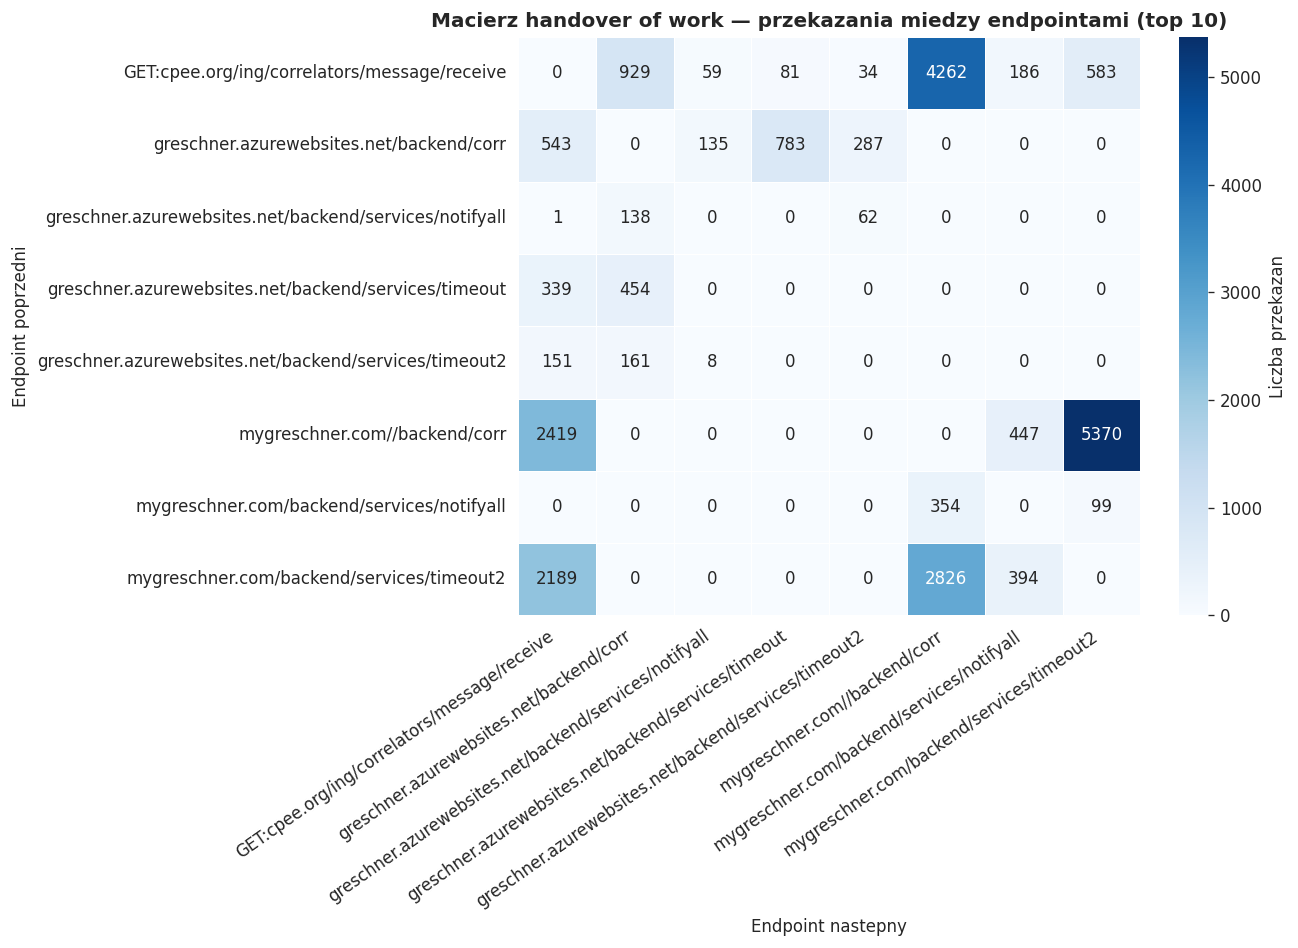

In [18]:
df_res_s = df_res.sort_values(['instance_uuid', 'timestamp'])
df_res_s = df_res_s.copy()
df_res_s['_next_ep'] = df_res_s.groupby('instance_uuid')['ep_short'].shift(-1)
hw = df_res_s.dropna(subset=['_next_ep'])
hw = hw[hw['ep_short'] != hw['_next_ep']]

top_ep  = ep_workload.head(10).index.tolist()
hw_mat  = hw.groupby(['ep_short', '_next_ep']).size().unstack(fill_value=0)
hw_top  = hw_mat.loc[
    hw_mat.index.isin(top_ep),
    [c for c in hw_mat.columns if c in top_ep]
]

fig_hw, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(hw_top, annot=True, fmt='d', cmap='Blues', ax=ax,
            cbar_kws={'label': 'Liczba przekazan'}, linewidths=0.5)
ax.set_title('Macierz handover of work — przekazania miedzy endpointami (top 10)', fontweight='bold')
ax.set_xlabel('Endpoint nastepny')
ax.set_ylabel('Endpoint poprzedni')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
fig_hw.savefig(RESULTS_DIR / 'fig_handover_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

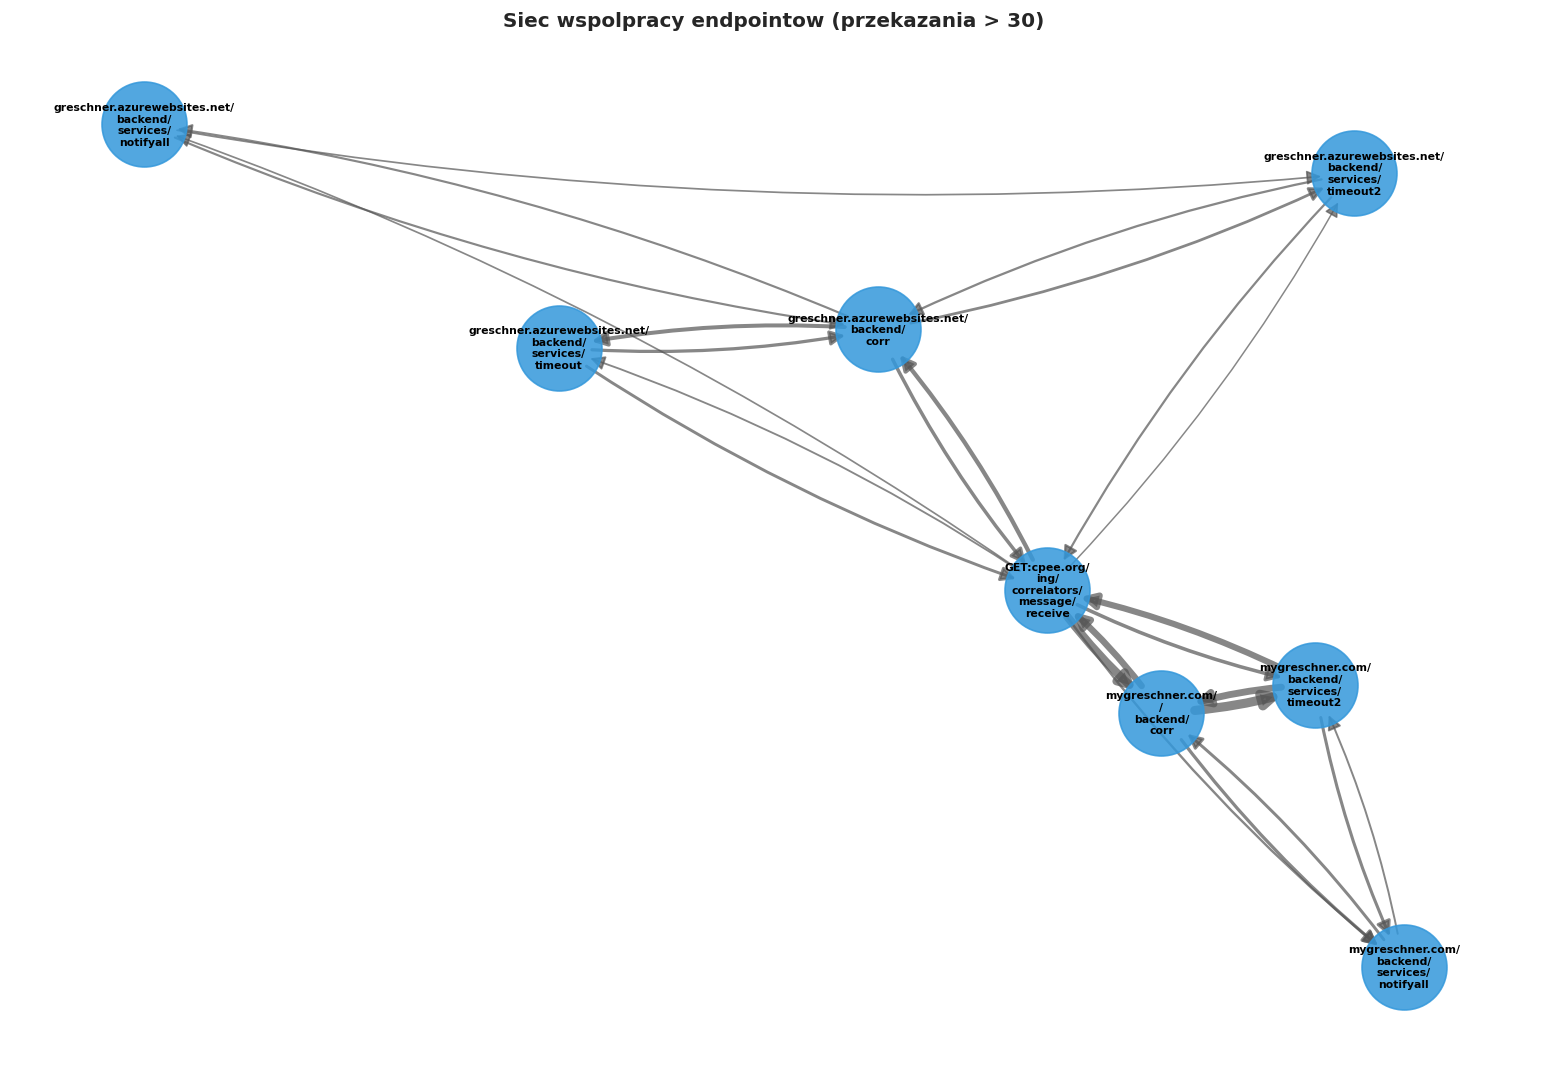

In [19]:
G_ep = nx.DiGraph()
for (src, tgt), cnt in hw.groupby(['ep_short', '_next_ep']).size().items():
    if cnt > 30:
        G_ep.add_edge(src, tgt, weight=int(cnt))

if G_ep.number_of_nodes() > 0:
    pos_ep = nx.spring_layout(G_ep, k=3.5, seed=42)
    ep_w   = [G_ep[u][v]['weight'] for u, v in G_ep.edges()]
    max_ew = max(ep_w)

    fig_sn, ax = plt.subplots(figsize=(13, 9))
    nx.draw_networkx_nodes(G_ep, pos_ep, ax=ax, node_size=2600,
                           node_color='#3498db', alpha=0.85)
    nx.draw_networkx_labels(G_ep, pos_ep, ax=ax, font_size=6.5, font_weight='bold',
                            labels={n: n.replace('/', '/\n') for n in G_ep.nodes()})
    nx.draw_networkx_edges(G_ep, pos_ep, ax=ax,
                           width=[0.5 + 5*(w/max_ew)**0.5 for w in ep_w],
                           alpha=0.70, edge_color='#555', arrows=True, arrowsize=18,
                           connectionstyle='arc3,rad=0.07',
                           min_source_margin=20, min_target_margin=20)
    ax.set_title('Siec wspolpracy endpointow (przekazania > 30)', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    fig_sn.savefig(RESULTS_DIR / 'fig_resource_network.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Brak krawedzi po filtrowaniu.')

## 8. Analiza wąskich gardeł i symulacja Monte Carlo

**Symulacja Monte Carlo** (N=2 000): dla każdego przebiegu losujemy wariant
z rozkładu empirycznego, a czasy przejść z empirycznych rozkładów.

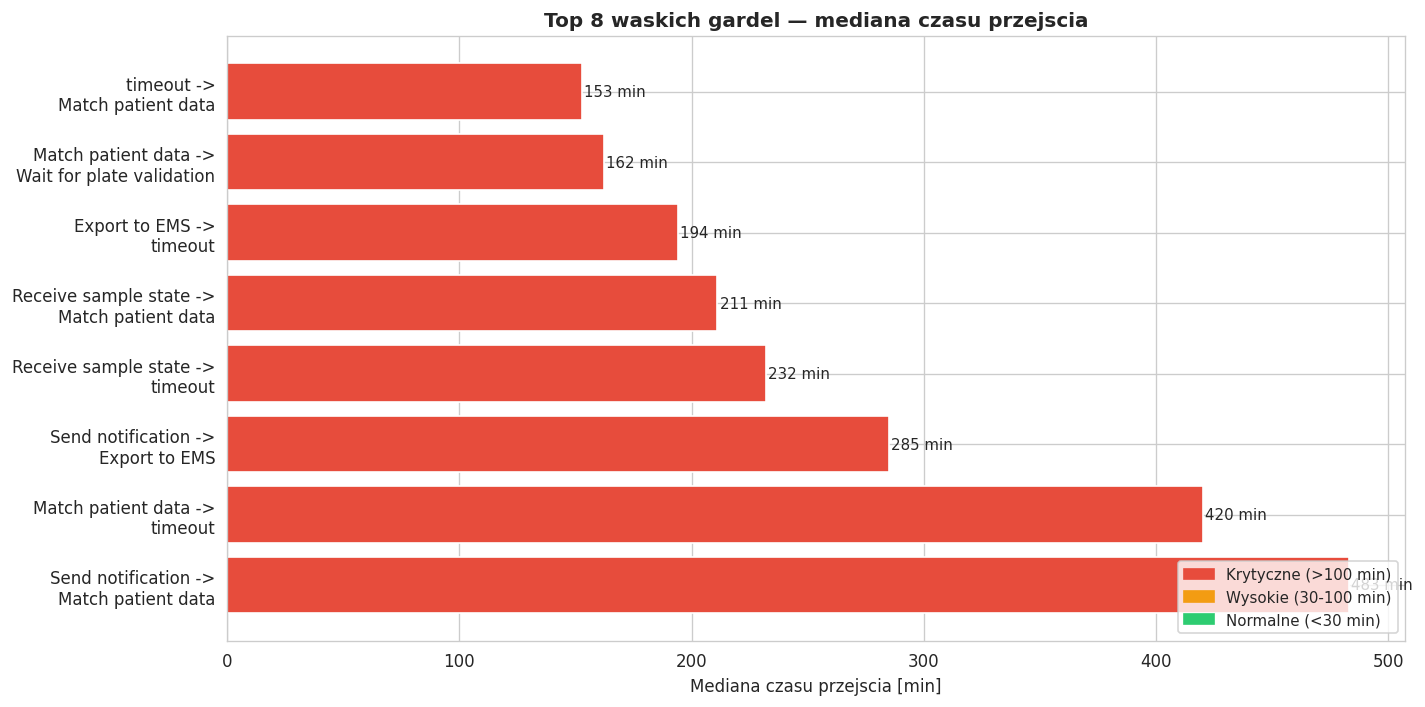

Waskie gardla (mediana):
  Send notification                   -> Match patient data                 :  483.1 min KRYTYCZNE
  Match patient data                  -> timeout                            :  420.1 min KRYTYCZNE
  Send notification                   -> Export to EMS                      :  284.8 min KRYTYCZNE
  Receive sample state                -> timeout                            :  232.0 min KRYTYCZNE
  Receive sample state                -> Match patient data                 :  211.1 min KRYTYCZNE
  Export to EMS                       -> timeout                            :  194.1 min KRYTYCZNE
  Match patient data                  -> Wait for plate validation          :  162.2 min KRYTYCZNE
  timeout                             -> Match patient data                 :  152.8 min KRYTYCZNE


In [20]:
top_bn = perf_dfg_df.nlargest(8, 'median').copy()
top_bn['median_min'] = top_bn['median'] / 60
top_bn['label'] = top_bn['activity'] + ' ->\n' + top_bn['_next_act']

colors_bn = ['#e74c3c' if m > 100 else '#f39c12' if m > 30 else '#2ecc71'
             for m in top_bn['median_min']]

fig_bn, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_bn['label'], top_bn['median_min'], color=colors_bn)
ax.set_xlabel('Mediana czasu przejscia [min]')
ax.set_title('Top 8 waskich gardel — mediana czasu przejscia', fontweight='bold')
for bar, val in zip(bars, top_bn['median_min']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} min', va='center', fontsize=9)
handles_bn = [
    mpatches.Patch(color='#e74c3c', label='Krytyczne (>100 min)'),
    mpatches.Patch(color='#f39c12', label='Wysokie (30-100 min)'),
    mpatches.Patch(color='#2ecc71', label='Normalne (<30 min)'),
]
ax.legend(handles=handles_bn, loc='lower right', fontsize=9)
plt.tight_layout()
fig_bn.savefig(RESULTS_DIR / 'fig_bottlenecks.png', dpi=120, bbox_inches='tight')
plt.show()

print('Waskie gardla (mediana):')
for _, r in top_bn.iterrows():
    flag = ' KRYTYCZNE' if r['median_min'] > 100 else (' Wysokie' if r['median_min'] > 30 else '')
    print(f'  {r["activity"]:35s} -> {r["_next_act"]:35s}: {r["median_min"]:6.1f} min{flag}')

=== Symulacja Monte Carlo (N=2000) ===
Symulacja:    mediana=174.9 min,  mean=336.1 min
Rzeczywiste:  mediana=175.3 min,  mean=331.0 min
P95 symulacja:    1228.4 min
P95 rzeczywiste:  1148.5 min


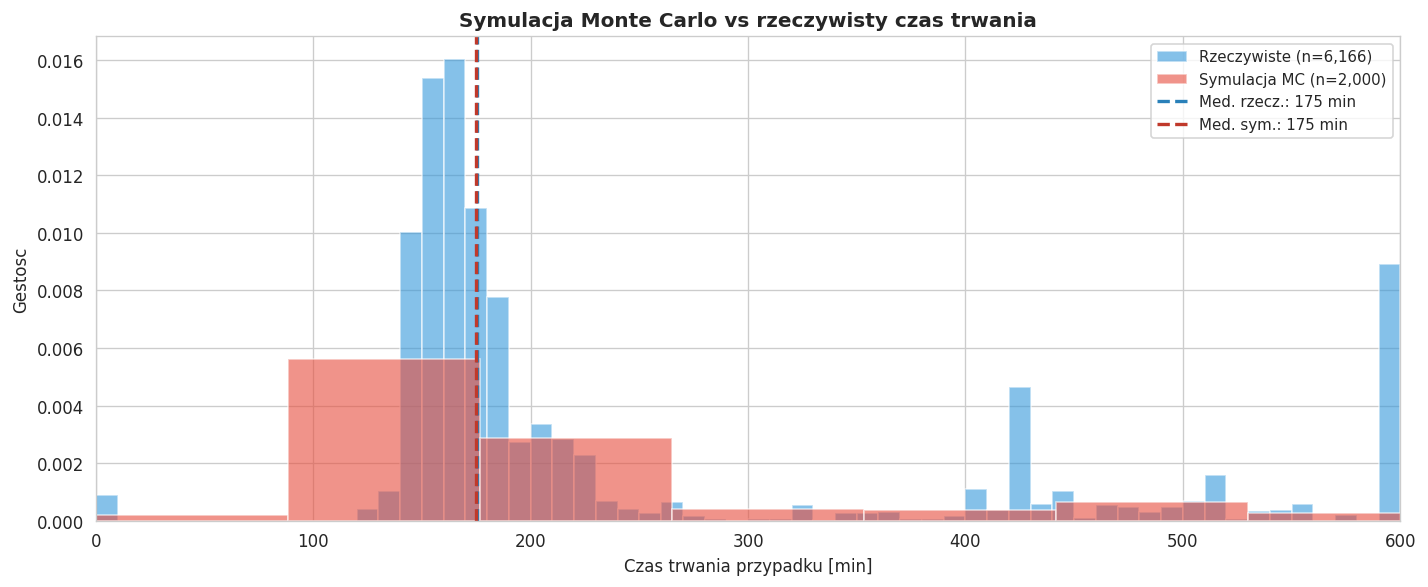

In [21]:
np.random.seed(RANDOM_STATE)
N_SIM = 2000

perf_dists = {}
for (act, nact), grp in df_perf.groupby(['activity', '_next_act']):
    perf_dists[(act, nact)] = grp['_dur_s'].values

variant_list = [t.split(' -> ') for t in traces['trace'].tolist()]

sim_durations = []
for _ in range(N_SIM):
    v = variant_list[np.random.randint(len(variant_list))]
    total = sum(
        float(np.random.choice(perf_dists[(v[i], v[i+1])]))
        for i in range(len(v) - 1)
        if (v[i], v[i+1]) in perf_dists and len(perf_dists[(v[i], v[i+1])]) > 0
    )
    sim_durations.append(total / 60)

sim_arr    = np.array(sim_durations)
actual_dur = df_cases_sample['duration_min'].dropna()

print(f'=== Symulacja Monte Carlo (N={N_SIM}) ===')
print(f'Symulacja:    mediana={np.median(sim_arr):.1f} min,  mean={np.mean(sim_arr):.1f} min')
print(f'Rzeczywiste:  mediana={actual_dur.median():.1f} min,  mean={actual_dur.mean():.1f} min')
print(f'P95 symulacja:    {np.percentile(sim_arr, 95):.1f} min')
print(f'P95 rzeczywiste:  {actual_dur.quantile(0.95):.1f} min')

fig_sim, ax = plt.subplots(figsize=(12, 5))
ax.hist(actual_dur.clip(0, 600), bins=60, alpha=0.6, color='#3498db',
        density=True, label=f'Rzeczywiste (n={len(actual_dur):,})')
ax.hist(sim_arr, bins=60, alpha=0.6, color='#e74c3c',
        density=True, label=f'Symulacja MC (n={N_SIM:,})')
ax.axvline(actual_dur.median(), color='#2980b9', linestyle='--', lw=2,
           label=f'Med. rzecz.: {actual_dur.median():.0f} min')
ax.axvline(np.median(sim_arr), color='#c0392b', linestyle='--', lw=2,
           label=f'Med. sym.: {np.median(sim_arr):.0f} min')
ax.set_xlabel('Czas trwania przypadku [min]')
ax.set_ylabel('Gestosc')
ax.set_title('Symulacja Monte Carlo vs rzeczywisty czas trwania', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 600)
plt.tight_layout()
fig_sim.savefig(RESULTS_DIR / 'fig_simulation.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Mini Dashboard HTML

6 paneli Plotly → jeden plik `results/m3/dashboard.html`.

In [22]:
fig_dash = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Top 15 przejsc DFG',
        'Rozklad czasu trwania [min]',
        'Top 10 wariantow',
        'Obciazenie endpointow (top 12)',
        'Waskie gardla — mediana [min]',
        'Conformance — Fitness / Precision / F1',
    ],
    vertical_spacing=0.18, horizontal_spacing=0.10,
)

top15 = sorted(dfg_freq.items(), key=lambda x: -x[1])[:15]
fig_dash.add_trace(go.Bar(
    x=[v for _, v in top15][::-1],
    y=[f'{s}->{t}' for (s, t), _ in top15][::-1],
    orientation='h', marker_color='#3498db'), row=1, col=1)

fig_dash.add_trace(go.Histogram(
    x=df_cases_sample['duration_min'].clip(0, 500).tolist(),
    nbinsx=50, marker_color='#2ecc71'), row=1, col=2)

top10v = variant_counts.head(10)
fig_dash.add_trace(go.Bar(
    x=top10v.values.tolist(),
    y=[f'V{i+1}' for i in range(len(top10v))],
    orientation='h', marker_color='#9b59b6',
    hovertext=list(top10v.index),
    hoverinfo='text+x'), row=1, col=3)

ep12 = ep_workload.head(12)
fig_dash.add_trace(go.Bar(
    x=ep12.values.tolist(), y=list(ep12.index),
    orientation='h', marker_color='#e67e22'), row=2, col=1)

bn_colors = ['#e74c3c' if m > 100 else '#f39c12' if m > 30 else '#2ecc71'
             for m in top_bn['median_min']]
fig_dash.add_trace(go.Bar(
    x=top_bn['median_min'].tolist(),
    y=[f"{r['activity']}->{r['_next_act']}" for _, r in top_bn.iterrows()],
    orientation='h', marker_color=bn_colors), row=2, col=2)

for metric, color in [('Fitness', '#3498db'), ('Precision', '#e74c3c'), ('F1', '#2ecc71')]:
    fig_dash.add_trace(go.Bar(
        name=metric, x=df_conform['Algorytm'].tolist(),
        y=df_conform[metric].fillna(0).tolist(), marker_color=color), row=2, col=3)

fig_dash.update_layout(
    height=900,
    title_text='<b>PCR Lab — Process Mining Dashboard (Milestone 3)</b>',
    title_font_size=16, showlegend=False, template='plotly_white', font=dict(size=9),
)

dash_path = RESULTS_DIR / 'dashboard.html'
fig_dash.write_html(str(dash_path), include_plotlyjs='cdn')
print(f'Dashboard zapisany: {dash_path}')
fig_dash.show()

Dashboard zapisany: /mnt/adata-disk/projects/agh/2stopien/BusinessModeling/results/m3/dashboard.html
